# From ObsPy to a moment tensor and back

The 2019-07-04 Ridgecrest foreshock (Mw 6.4, 17:33:49 UTC) inverted for its moment tensor without leaving ObsPy:
FDSN web services give the catalogue `Event`, the station `Inventory` and the waveform `Stream`; the library turns
them into a data vector and a noise covariance, fits a moment tensor, and hands back the synthetics as a `Stream`
and the posterior as a QuakeML `Event`. No configuration file, station file or HDF5 file is written by hand.

With `ONLINE = False` the notebook reads the same data from `data/ridgecrest/` (its README lists the calls), so it
runs offline; set it to `True` to download them afresh. The forward model is an Instaseis database that resolves
20 s periods, such as `prem_a_20s`.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from obspy import Catalog, Inventory, Stream, UTCDateTime, read, read_events, read_inventory
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth

from seismo_sbi.data_handling.preprocessing.processing import deconvolve_and_filter
from seismo_sbi.data_handling.preprocessing.sbi_export import observation_from_stream, pre_event_autocorrelations
from seismo_sbi.moment_tensor.comparison import kagan
from seismo_sbi.moment_tensor.conventions import moment_magnitude
from seismo_sbi.moment_tensor.quakeml import moment_tensor_from_tensor, posterior_event, source_location_from_origin
from seismo_sbi.sbi.compression.gaussian import GaussianCompressor, ScoreCompressionData
from seismo_sbi.sbi.noises.toeplitz_covariances import BlockDiagonalEmpiricalCovariance
from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator
from seismo_sbi.simulators.receivers import Receivers
from seismo_sbi.simulators.simulation_io import seismogram_map_to_array
from seismo_sbi.simulators.synthetic_stream import seismogram_map_to_stream

ONLINE = False
DATA = Path("data/ridgecrest")
DATABASE = os.environ.get("INSTASEIS_DB_20S", "/data/shared/prem_a_20s")
ORIGIN_TIME = UTCDateTime("2019-07-04T17:33:49")
BAND_HZ = (0.02, 0.05)
SAMPLING_RATE_HZ = 0.5

## The event and its published moment tensors

The USGS event carries the USGS (Mww, Mwb) and Southern California Seismic Network tensors; the ISC event adds
GCMT and GFZ, each with the centroid it was derived at. Tensors that ISC copies from the USGS are listed once, and
Mw is computed from each tensor's scalar moment.

In [2]:
if ONLINE:
    catalogue = Client("USGS").get_events(eventid="ci38443183", includeallorigins=True, includeallmagnitudes=True)
    catalogue += Client("ISC").get_events(starttime=ORIGIN_TIME - 60, endtime=ORIGIN_TIME + 60, minmagnitude=6,
                                          includeallorigins=True, includeallmagnitudes=True)
else:
    catalogue = read_events(DATA / "events.xml.gz")
hypocentre = catalogue[0].preferred_origin()
AGENCIES = {"us": "USGS", "CI": "SCSN"}

published, centroids = {}, {}
for mechanism in (mechanism for event in catalogue for mechanism in event.focal_mechanisms):
    if mechanism.moment_tensor is None or mechanism.moment_tensor.tensor is None:
        continue
    m6 = moment_tensor_from_tensor(mechanism.moment_tensor.tensor)
    agency = AGENCIES.get(mechanism.creation_info.agency_id, mechanism.creation_info.author)
    if any(np.allclose(m6, other, rtol=1e-3) for other in published.values()):
        continue
    label = f"{agency} Mw {moment_magnitude(m6):.2f}"
    published[label] = m6
    if mechanism.moment_tensor.derived_origin_id is not None:
        centroids[label] = mechanism.moment_tensor.derived_origin_id.get_referred_object()

print(f"hypocentre {hypocentre.latitude:.3f} N {-hypocentre.longitude:.3f} W, depth {hypocentre.depth / 1e3:.1f} km")
for label in published:
    centroid = centroids.get(label)
    where = (f"centroid depth {centroid.depth / 1e3:4.1f} km, {centroid.time - hypocentre.time:4.1f} s after the hypocentre"
             if centroid is not None else "")
    print(f"{label:16s} {where}")

hypocentre 35.705 N 117.504 W, depth 10.5 km
SCSN Mw 6.39     
USGS Mw 6.47     
USGS Mw 6.32     
GCMT Mw 6.45     centroid depth 12.7 km,  9.4 s after the hypocentre
GFZ Mw 6.41      centroid depth 12.0 km,  2.0 s after the hypocentre


## Stations and waveforms

Eight broadband stations 2 to 4 degrees away (at least ten rupture lengths), chosen for a high signal-to-noise
ratio at 20-50 s, no clipping, and azimuthal coverage with no gap above 66 degrees. Each network is served by its
own data centre. The rupture is about 15-20 km long and lasts about 8 s; at 20-50 s the wavelengths are 70 km and
more and the periods several source durations, so a point source at the centroid describes the waves.

In [3]:
STATIONS = {"SCEDC": [("CI", "PDM", "", "BH?"), ("CI", "SCI2", "", "BH?"), ("CI", "SMR", "", "BH?")],
            "NCEDC": [("BK", "PACP", "00", "BH?"), ("BK", "WELL", "00", "BH?")],
            "EARTHSCOPE": [("NN", "Q09A", "", "HH?"), ("NN", "SHP", "", "HH?"), ("PY", "BPH05", "", "BH?")]}
if ONLINE:
    raw, inventory = Stream(), Inventory()
    for centre, codes in STATIONS.items():
        client = Client(centre)
        for network, station, location, channel in codes:
            raw += client.get_waveforms(network, station, location, channel, ORIGIN_TIME - 1500, ORIGIN_TIME + 500)
            inventory += client.get_stations(network=network, station=station, location=location, channel=channel,
                                             starttime=ORIGIN_TIME - 1500, endtime=ORIGIN_TIME + 500, level="response")
    raw.merge(method=0).detrend("linear").resample(1.0)
else:
    raw, inventory = read(DATA / "waveforms.mseed"), read_inventory(DATA / "stations.xml.gz")

receivers = Receivers.from_inventory(inventory)
geometry = {receiver.station_name: gps2dist_azimuth(hypocentre.latitude, hypocentre.longitude, receiver.latitude,
                                                    receiver.longitude)[:2] for receiver in receivers}
for receiver in receivers:
    distance_m, azimuth_deg = geometry[receiver.station_name]
    print(f"{receiver.network}.{receiver.station_name:6s} {distance_m / 111.19e3:4.2f} deg  azimuth {azimuth_deg:5.1f} deg")

CI.PDM    3.09 deg  azimuth 115.9 deg
CI.SCI2   2.85 deg  azimuth 197.9 deg
CI.SMR    2.56 deg  azimuth 263.5 deg
BK.PACP   3.32 deg  azimuth 294.2 deg
BK.WELL   3.75 deg  azimuth 317.6 deg
NN.Q09A   3.13 deg  azimuth   4.6 deg
NN.SHP    2.06 deg  azimuth  66.5 deg
PY.BPH05  2.26 deg  azimuth 157.2 deg


## The observation and its noise, straight from the `Stream`

The response is removed to displacement, the horizontals are rotated to north and east, and the traces are
band-passed at 20-50 s and resampled to 0.5 Hz. The event window starts 60 s before the origin time, as the
Instaseis synthetics do, and runs for 350 s. The noise covariance comes from the 1200 s before the window.

In [4]:
processed = deconvolve_and_filter(raw, inventory, filter_kwargs=dict(freqmin=BAND_HZ[0], freqmax=BAND_HZ[1]),
                                  target_sr=SAMPLING_RATE_HZ)
window = (ORIGIN_TIME - 60, ORIGIN_TIME + 290)
observed, present = observation_from_stream(processed, receivers, window, SAMPLING_RATE_HZ)
n_samples = observed.size // (3 * len(receivers))
noise = pre_event_autocorrelations(processed, [receiver.station_name for receiver in receivers], window[0], 1200.0)
noise_covariance = BlockDiagonalEmpiricalCovariance(noise, receivers, n_samples, num_jobs=1)
print(f"{present.sum()} of {len(receivers)} stations present, {observed.size} samples "
      f"({n_samples} per trace), peak displacement {np.abs(observed).max() * 1e3:.2f} mm")

8 of 8 stations present, 4224 samples (176 per trace), peak displacement 2.29 mm


## Least squares at the hypocentre and at the centroid

The seismograms are linear in the six moment-tensor components, so six simulations give the kernels and the
least-squares tensor follows directly. Waves at 20-50 s see the centroid: GCMT puts it 12.7 km deep and 9.4 s
after the hypocentral origin time, half a cycle at 20 s. Only GCMT's centroid position and time are borrowed; the
mechanism is fitted independently.

In [5]:
simulator = InstaseisSourceSimulator(
    DATABASE, components="ZEN", receivers=receivers, seismogram_duration_in_s=350.0,
    synthetics_processing={"filter": {"type": "bandpass", "freqmin": BAND_HZ[0], "freqmax": BAND_HZ[1],
                                      "corners": 4, "zerophase": False},
                           "sampling_rate": SAMPLING_RATE_HZ, "filter_sampling_rate": 1.0})


def kernels_at(source):
    """``(6, n_data)`` synthetics of the six unit moment tensors at ``source``."""
    return np.array([seismogram_map_to_array(simulator.run_simulation(
        {"source_location": list(source), "moment_tensor": list(unit)})[1], receivers) for unit in np.eye(6)])


sources = {"hypocentre": source_location_from_origin(hypocentre),
           "GCMT centroid": source_location_from_origin(centroids[next(l for l in centroids if l.startswith("GCMT"))],
                                                        origin_time_utc=hypocentre.time)}
kernels = {name: kernels_at(source) for name, source in sources.items()}
for name, source in sources.items():
    least_squares, *_ = np.linalg.lstsq(kernels[name].T, observed, rcond=None)
    reduction = 1 - np.sum((observed - kernels[name].T @ least_squares) ** 2) / np.sum(observed ** 2)
    print(f"{name:14s} depth {source.depth:4.1f} km, {source.time_shift:4.1f} s: variance reduction {reduction:.2f}, "
          f"Mw {moment_magnitude(least_squares):.2f}")

hypocentre     depth 10.5 km,  0.0 s: variance reduction 0.19, Mw 6.11
GCMT centroid  depth 12.7 km,  9.4 s: variance reduction 0.59, Mw 6.28


## The Gaussian-likelihood posterior

Score compression with the empirical noise covariance gives the Gaussian-likelihood posterior in closed form: its
mean is the weighted least-squares tensor and its covariance the inverse Fisher matrix. The covariance describes
the pre-event noise alone. $\chi^2/N \approx 10^7$ says the residual is about ten million times what that noise
can explain: the misfit is modelling error, here 1-D PREM at 2-4 degrees and 20-50 s, which the noise covariance
does not describe. The width of this posterior is therefore not credible; building those errors into the
inference is what the next notebook is for.

In [6]:
centroid_kernels = kernels["GCMT centroid"]
compressor = GaussianCompressor(ScoreCompressionData(np.zeros(6), np.zeros(observed.size), centroid_kernels, None),
                                noise_covariance)
posterior_mean, posterior_covariance = compressor.compress_data_vector(observed), compressor.Fisher_mat_inverse
posterior_samples = np.random.default_rng(0).multivariate_normal(posterior_mean, posterior_covariance, size=4000)
residual = observed - centroid_kernels.T @ posterior_mean
print(f"chi2 / N = {-2 * noise_covariance.compute_loss(residual) / observed.size:.1e}; Mw "
      f"{moment_magnitude(posterior_mean):.2f} +- {moment_magnitude(posterior_samples).std():.0e}")

chi2 / N = 1.0e+07; Mw 6.24 +- 2e-06


## Synthetics as a `Stream`, over the data

The posterior-mean synthetics come back as an ObsPy `Stream` on the same time base as the data, ready for any
ObsPy tool. Stations are ordered by azimuth.

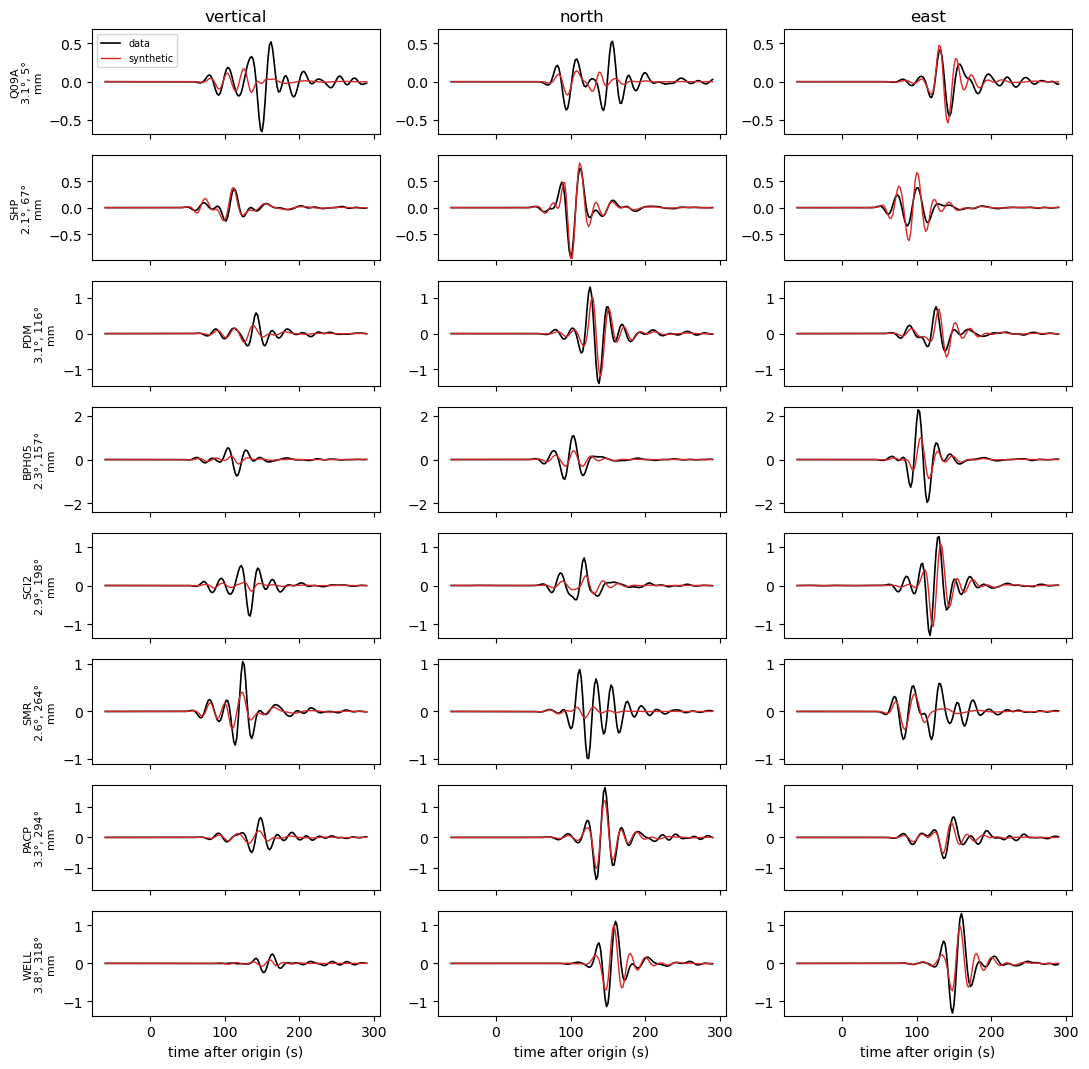

In [7]:
synthetics = seismogram_map_to_stream(simulator.run_simulation(
    {"source_location": list(sources["GCMT centroid"]), "moment_tensor": list(posterior_mean)})[1],
    simulator, hypocentre.time)
data = processed.slice(*window)
order = sorted(geometry, key=lambda station: geometry[station][1])
fig, axes = plt.subplots(len(order), 3, figsize=(11, 1.35 * len(order)), sharex=True)
for row, station in zip(axes, order):
    scale_mm = 1.05e3 * max(np.abs(trace.data).max() for trace in data.select(station=station))
    for ax, component in zip(row, "ZNE"):
        for stream, style in ((data, dict(color="k", lw=1.2, label="data")),
                              (synthetics, dict(color="C3", lw=1.0, label="synthetic"))):
            trace = stream.select(station=station, component=component)[0]
            ax.plot(trace.times() + (trace.stats.starttime - hypocentre.time), trace.data * 1e3, **style)
        ax.set_ylim(-scale_mm, scale_mm)
    distance_m, azimuth_deg = geometry[station]
    row[0].set_ylabel(f"{station}\n{distance_m / 111.19e3:.1f}°, {azimuth_deg:.0f}°\nmm", fontsize=8)
for ax, component in zip(axes[0], "ZNE"):
    ax.set_title({"Z": "vertical", "N": "north", "E": "east"}[component])
for ax in axes[-1]:
    ax.set_xlabel("time after origin (s)")
axes[0, 0].legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

## The posterior as QuakeML, and the published tensors

`posterior_event` reports the posterior as an ObsPy `Event`: the mean tensor with each component's posterior
standard deviation, the scalar moment, the double-couple, CLVD and isotropic fractions, the nodal planes, the
principal axes and Mw. It is a point estimate with marginal spreads: correlations between components and the
posterior's shape on the lune are not carried. Written next to the catalogue event and read back, it is compared
with every published tensor by Kagan angle.

In [8]:
posterior = posterior_event(posterior_samples, centroids[next(l for l in centroids if l.startswith("GCMT"))])
Catalog([catalogue[0], posterior]).write("ridgecrest_with_posterior.xml", format="QUAKEML")
written = read_events("ridgecrest_with_posterior.xml")
mechanism = written[1].preferred_focal_mechanism()
ours = moment_tensor_from_tensor(mechanism.moment_tensor.tensor)
planes = [mechanism.nodal_planes.nodal_plane_1, mechanism.nodal_planes.nodal_plane_2]
print(f"this posterior: Mw {written[1].preferred_magnitude().mag:.2f}, double couple "
      f"{100 * mechanism.moment_tensor.double_couple:.0f} %, nodal planes (strike/dip/rake) "
      + " and ".join(f"{plane.strike:.0f}/{plane.dip:.0f}/{plane.rake:.0f}" for plane in planes))
for label, m6 in published.items():
    print(f"{label:16s} Kagan angle to this posterior's mean {kagan(ours, m6):5.1f} deg")

this posterior: Mw 6.24, double couple 64 %, nodal planes (strike/dip/rake) 310/84/-174 and 219/84/-6
SCSN Mw 6.39     Kagan angle to this posterior's mean  21.5 deg
USGS Mw 6.47     Kagan angle to this posterior's mean   9.5 deg
USGS Mw 6.32     Kagan angle to this posterior's mean  11.7 deg
GCMT Mw 6.45     Kagan angle to this posterior's mean  12.0 deg
GFZ Mw 6.41      Kagan angle to this posterior's mean   7.4 deg


The fitted mechanism lies within 7 to 22 degrees of every published tensor. Its moment magnitude, 6.24, is below
the published 6.32 to 6.47, and its posterior, built on the noise covariance alone, is far narrower than the spread
between the agencies.